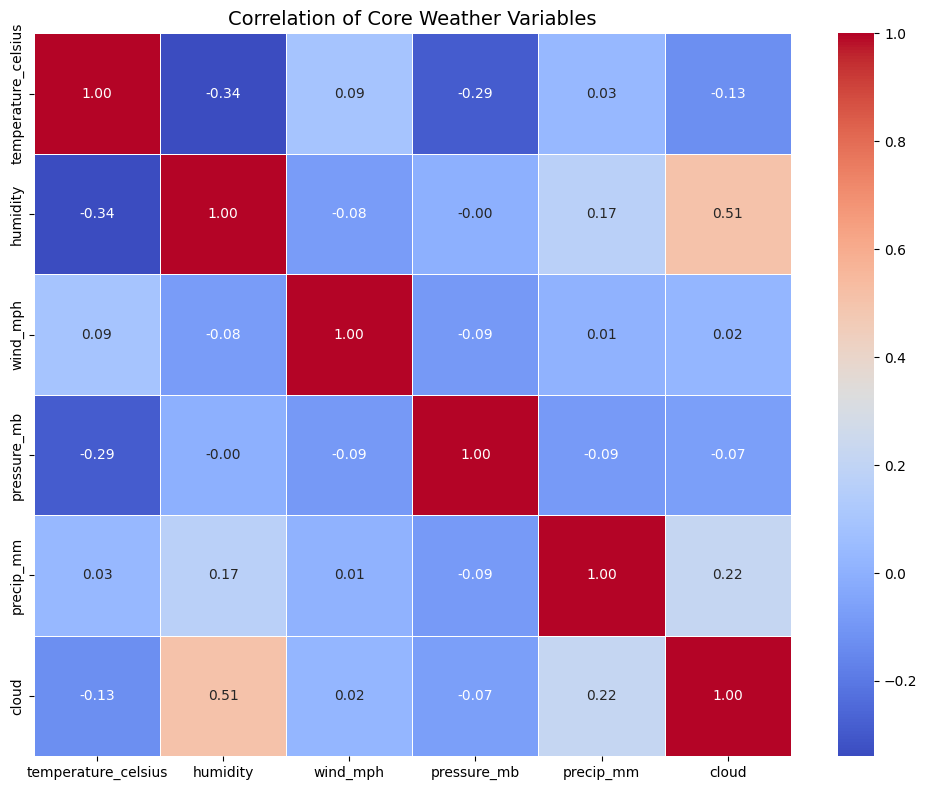

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load the CLEANED dataset
df = pd.read_csv('../data/GlobalWeatherRepository_Cleaned.csv')
# Ensure date is a datetime object again just in case
df['date'] = pd.to_datetime(df['date'])

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Select key numerical columns
cols_to_corr = ['temperature_celsius', 'humidity', 'wind_mph', 'pressure_mb', 'precip_mm', 'cloud']
corr_matrix = df[cols_to_corr].corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation of Core Weather Variables', fontsize=14)
plt.tight_layout()

# Save it to your outputs folder for the final report!
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

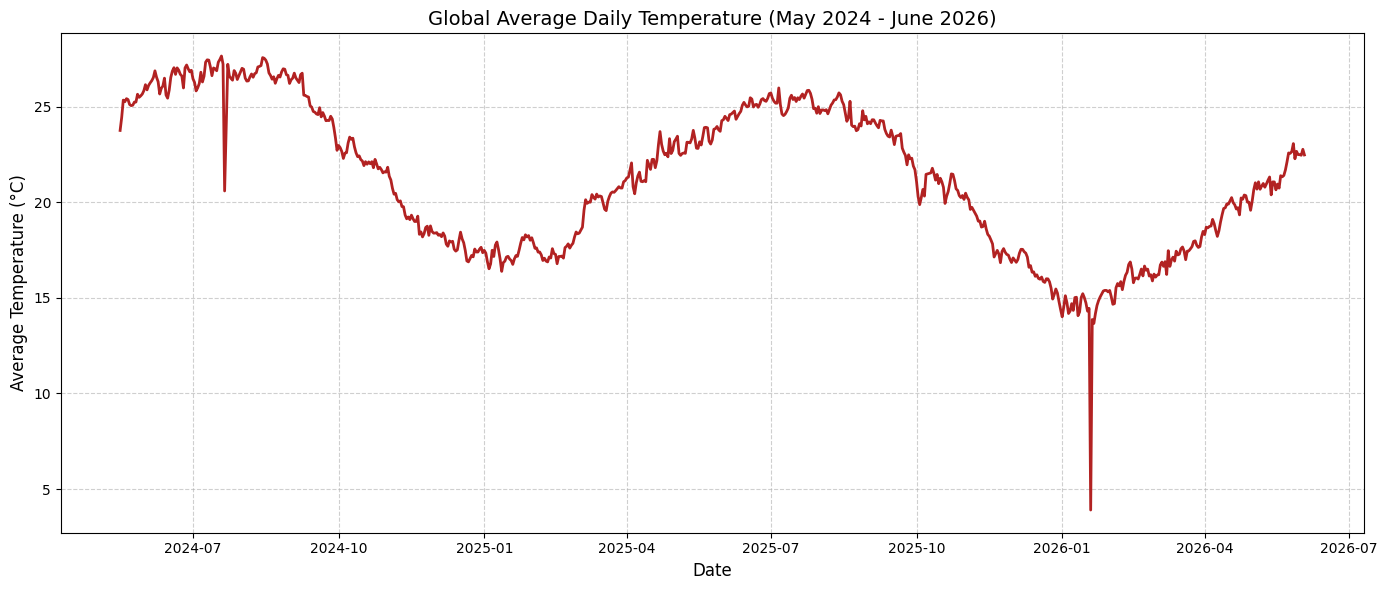

In [2]:
# Group by date to get the global daily average temperature
daily_temp = df.groupby('date')['temperature_celsius'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(daily_temp['date'], daily_temp['temperature_celsius'], color='firebrick', linewidth=2)
plt.title('Global Average Daily Temperature (May 2024 - June 2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('../outputs/global_temp_trend.png')
plt.show()

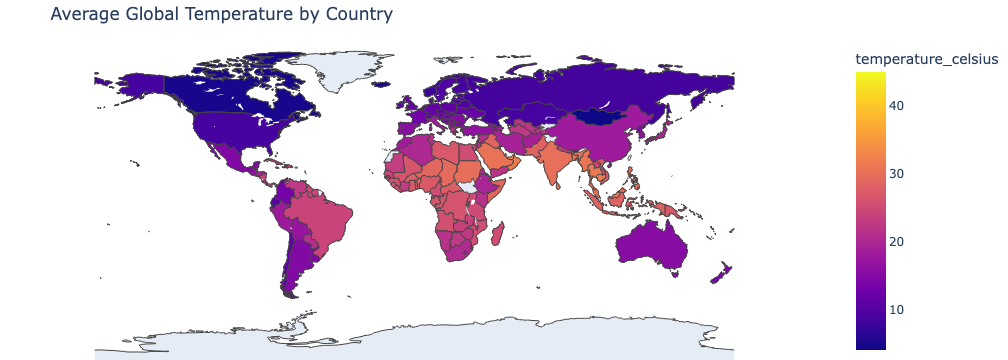

In [3]:
# Get the average temperature per country across the whole dataset
country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()

# Create an interactive Choropleth map
fig = px.choropleth(
    country_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Average Global Temperature by Country"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
    margin={"r":0,"t":40,"l":0,"b":0}
)

# Save as an interactive HTML file so you can show it off in your demo video
fig.write_html('../outputs/interactive_temp_map.html')
fig.show()

### EDA Insights & The Anomaly Trap
* **Correlations:** The heatmap reveals that the strongest positive relationship exists between humidity and cloud cover (0.51). Temperature shows an expected negative correlation with both pressure (-0.29) and humidity (-0.34).
* **Seasonality & Anomalies:** The time-series plot confirms clear yearly seasonality, which validates the use of seasonal forecasting models later. However, **critical data anomalies exist**. There are massive, physically impossible downward spikes in the global average temperature (e.g., dropping near 5°C in early 2026). These outliers must be isolated before modeling.

Training Isolation Forest to detect anomalies...

Anomaly Counts:
anomaly_flag
Normal (1)      143759
Anomaly (-1)      1453
Name: count, dtype: int64


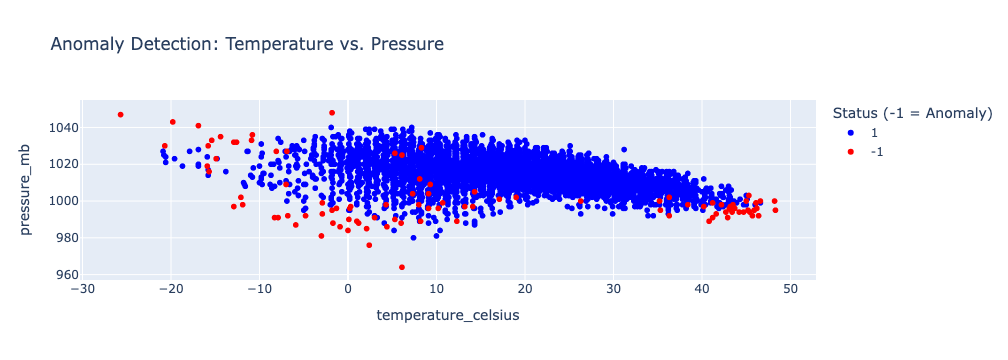

In [4]:
from sklearn.ensemble import IsolationForest
import plotly.express as px

print("Training Isolation Forest to detect anomalies...")

# We will look for anomalies across our core features
features = ['temperature_celsius', 'wind_mph', 'pressure_mb']

# Initialize the model (telling it to flag the weirdest 1% of our data)
iso = IsolationForest(contamination=0.01, random_state=42)

# Fit the model and predict (-1 means it's an anomaly, 1 means it's normal)
df['anomaly_flag'] = iso.fit_predict(df[features])

# Let's see how many anomalies it found!
print("\nAnomaly Counts:")
print(df['anomaly_flag'].value_counts().rename({1: 'Normal (1)', -1: 'Anomaly (-1)'}))

# Let's visualize where these anomalies are on a scatter plot
fig = px.scatter(
    df.sample(10000, random_state=42), # Sampling 10k rows so the browser doesn't crash
    x='temperature_celsius', 
    y='pressure_mb', 
    color=df.sample(10000, random_state=42)['anomaly_flag'].astype(str),
    color_discrete_map={'-1': 'red', '1': 'blue'},
    title='Anomaly Detection: Temperature vs. Pressure',
    labels={'color': 'Status (-1 = Anomaly)'}
)

# Save the plot for the report
fig.write_html('../outputs/anomaly_scatter.html')
fig.show()

In [5]:
# Filter out the anomalies (-1) and keep only normal data (1)
df_clean = df[df['anomaly_flag'] == 1].copy()

# Drop the flag column since we don't need it anymore
df_clean = df_clean.drop(columns=['anomaly_flag'])

print(f"Original row count: {len(df)}")
print(f"Cleaned row count ready for modeling: {len(df_clean)}")

# Save this ultimate clean version for our models
df_clean.to_csv('../data/GlobalWeatherRepository_Modeling.csv', index=False)
print("Modeling dataset saved successfully!")

Original row count: 145212
Cleaned row count ready for modeling: 143759
Modeling dataset saved successfully!
